# 03 — Modelos Avanzados, Interpretabilidad y Equidad
## Sistema de Alerta Temprana para Orientación Universitaria
### Pregunta D · TSDS 2025/2026 · Grupo 6

---

### Contexto y objetivo

La regresión logística estableció una referencia sólida: AUC 0.693, recall 0.658 en la clase de alerta. Este notebook tiene tres objetivos distintos.

El primero es mejorar ese rendimiento mediante modelos que capturen interacciones y no linealidades que la logística no puede modelar. El techo teórico del problema, estimado a partir de la señal disponible en el dataset (V de Cramér máximo 0.264), está en torno a AUC 0.73-0.76. La señal es limitada por naturaleza — la inserción laboral depende de variables del mercado que ninguna encuesta pre-graduación puede capturar — pero hay margen real que explotar mediante ingeniería de features e interacciones.

El segundo es extraer interpretabilidad con SHAP para responder a las preguntas del caso de negocio: qué factores pesan más globalmente y cómo explicar al orientador la alerta de un alumno concreto.

El tercero, y quizás el más revelador, es auditar la equidad del modelo. El análisis de los resultados muestra que el modelo tiene un problema grave de calibración por rama académica que hay que documentar y discutir honestamente.

---

### Estructura del notebook

1. Imports, datos y pipeline base
2. Ingeniería de features de interacción
3. Entrenamiento y comparativa de cuatro modelos basados en árboles
4. Optimización exhaustiva del modelo ganador
5. Stacking ensemble
6. Tabla final comparativa
7. Interpretabilidad SHAP: análisis global e individual
8. Análisis de equidad: fairness por género y por rama
9. Calibración por rama y optimización de umbral
10. Conclusiones e implicaciones para el producto


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
from IPython.display import display
from time import time

# Pipeline y preprocesado
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder, FunctionTransformer
)
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import lightgbm as lgb

# Evaluación
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score, confusion_matrix,
    recall_score, precision_score, roc_curve, brier_score_loss,
    classification_report
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Interpretabilidad
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

COLOR_RIESGO  = '#E74C3C'
COLOR_EXITO   = '#27AE60'
COLOR_NEUTRAL = '#2C3E50'
COLOR_ACCENT  = '#F39C12'
COLOR_LGB     = '#8E44AD'
COLOR_XGB     = '#2980B9'

print(f"lightgbm {lgb.__version__}  |  xgboost {xgb.__version__}  |  shap {shap.__version__}")
print(f"scikit-learn {__import__('sklearn').__version__}")


lightgbm 4.6.0  |  xgboost 3.2.0  |  shap 0.51.0
scikit-learn 1.6.1


---
## Sección 1. Carga de Datos y Pipeline Base

El pipeline de preprocesado es el mismo del notebook 02. Se añade en la siguiente sección una capa de ingeniería de features de interacción que se aplica sobre el dataset antes del pipeline.


In [2]:
# ── Carga ─────────────────────────────────────────────────────
base = '../data/processed/' if os.getcwd().endswith('notebooks') else 'data/processed/'

X_train = pd.read_csv(base + 'X_train.csv', index_col=0)
X_test  = pd.read_csv(base + 'X_test.csv',  index_col=0)
y_train = pd.read_csv(base + 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(base + 'y_test.csv',  index_col=0).squeeze()

ruta_fig = '../outputs/figures/' if os.getcwd().endswith('notebooks') else 'outputs/figures/'
os.makedirs(ruta_fig, exist_ok=True)

ratio_clases = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Ratio clases (neg/pos): {ratio_clases:.2f}")

# ── Pipeline base (idéntico al notebook 02) ───────────────────
COLS_TARGET_ENC        = ['TITU', 'AMBITO']
COLS_OHE               = ['SEXO','NACIO','DISCA','EDAD','RAMA','T_UNIV',
                           'ESTUDIOS_PADRE','ESTUDIOS_MADRE','MVFUERA','EST_M1',
                           'HL_E1','HL_E3','EST_B1','EST_B2_1','EST_B2_4','MOVILIDAD_INTL']
COLS_ORDINAL           = ['TIC', 'IDIOMAS', 'NIV_ID1']
COLS_ORDINAL_NULO_INFO = ['NIV_ID2']
COLS_NUMERIC           = ['CAPITAL_CULTURAL','NIVEL_IDIOMA_MAX',
                           'PRACTICAS_CALIDAD','PERFIL_GLOBAL','HL_E2']

def construir_preprocessor(cols_target=COLS_TARGET_ENC, cols_ohe=COLS_OHE,
                            cols_ord=COLS_ORDINAL, cols_niv=COLS_ORDINAL_NULO_INFO,
                            cols_num=COLS_NUMERIC):
    """Construye el ColumnTransformer. Se llama cada vez que se necesita
    una instancia nueva para evitar problemas de estado entre pipelines."""
    return ColumnTransformer(
        transformers=[
            ('target_enc', Pipeline([
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('enc', TargetEncoder(smooth='auto', random_state=42)),
            ]), cols_target),
            ('ohe', Pipeline([
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('enc', OneHotEncoder(handle_unknown='ignore',
                                      sparse_output=False, drop='if_binary')),
            ]), cols_ohe),
            ('ordinal', Pipeline([
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('enc', OrdinalEncoder(handle_unknown='use_encoded_value',
                                       unknown_value=-1)),
            ]), cols_ord),
            ('niv_id2', Pipeline([
                ('imp', SimpleImputer(strategy='constant', fill_value=0)),
                ('enc', OrdinalEncoder()),
            ]), cols_niv),
            ('numeric', Pipeline([
                ('imp', SimpleImputer(strategy='median')),
                ('scl', StandardScaler()),
            ]), cols_num),
        ],
        remainder='drop',
        verbose_feature_names_out=False
    )

# Referencia del notebook 02
BASELINE_LR = {
    'ROC-AUC': 0.6928, 'F1 (alerta)': 0.4834,
    'Recall (alerta)': 0.6576, 'Precision': 0.3822,
    'Accuracy': 0.6320, 'Gap AUC': 0.0097,
}
print(f"\nReferencia logística (CV k=5): AUC={BASELINE_LR['ROC-AUC']:.4f}")


Train: (25320, 27)  |  Test: (6331, 27)
Ratio clases (neg/pos): 2.82

Referencia logística (CV k=5): AUC=0.6928


---
## Sección 2. Ingeniería de Features de Interacción

El análisis SHAP del modelo inicial reveló que TITU y AMBITO concentran el 45% de la importancia total, y que SEXO es el cuarto predictor más importante (por encima de TIC). Esto indica que el modelo aprende una señal real de género que no está completamente mediada por la rama o la titulación.

El diagnóstico de fairness confirmó un problema de calibración severo por rama: el modelo alerta al 90% de los estudiantes de Artes (FPR=0.867) mientras que ignora al 87.6% de los estudiantes de Ingeniería que sí están en riesgo. Esto ocurre porque el modelo aprende P(alerta | RAMA) de forma casi determinista para las ramas extremas, sin poder distinguir bien dentro de ellas.

La ingeniería de interacciones intenta romper esta lógica. Si el modelo tiene acceso a combinaciones RAMA×TIC y RAMA×HL_E3 como features explícitas, puede aprender que un estudiante de Artes con TIC avanzado tiene un perfil diferente al de un estudiante de Artes con TIC básico, en lugar de tratar a todos los estudiantes de Artes de forma similar.

Se crean cuatro features nuevas:

| Feature | Construcción | Hipótesis |
|---|---|---|
| `RAMA_TIC` | Concatenación RAMA-TIC | TIC protege de forma diferente según la rama |
| `RAMA_HL_E3` | Concatenación RAMA-HL_E3 | Trabajar durante estudios importa más en algunas ramas |
| `SEXO_RAMA` | Concatenación SEXO-RAMA | El efecto de género varía según la rama |
| `TITU_FREQ` | Frecuencia relativa de cada TITU en train | Proxy del tamaño del mercado laboral por titulación |


In [3]:
# ── Creación de features de interacción ───────────────────────
def añadir_interacciones(df, df_ref=None):
    """
    Añade features de interacción. df_ref se usa para calcular frecuencias
    de TITU en train (evita leakage: el test usa las frecuencias del train).
    """
    df = df.copy()

    # Variables base numéricas
    rama   = pd.to_numeric(df['RAMA'],   errors='coerce').fillna(0).astype(int)
    tic    = pd.to_numeric(df['TIC'],    errors='coerce').fillna(0).astype(int)
    hl_e3  = pd.to_numeric(df['HL_E3'], errors='coerce').fillna(0).astype(int)
    sexo   = pd.to_numeric(df['SEXO'],  errors='coerce').fillna(0).astype(int)

    # Interacciones como strings (para OHE posterior)
    df['RAMA_TIC']   = rama.astype(str) + '_' + tic.astype(str)
    df['RAMA_HL_E3'] = rama.astype(str) + '_' + hl_e3.astype(str)
    df['SEXO_RAMA']  = sexo.astype(str) + '_' + rama.astype(str)

    # Frecuencia de TITU (calculada sobre df_ref para evitar leakage)
    ref = df_ref if df_ref is not None else df
    titu_freq = ref['TITU'].value_counts(normalize=True)
    df['TITU_FREQ'] = df['TITU'].map(titu_freq).fillna(titu_freq.min())

    return df

X_train_fe = añadir_interacciones(X_train, df_ref=X_train)
X_test_fe  = añadir_interacciones(X_test,  df_ref=X_train)

# Verificar
nuevas = ['RAMA_TIC', 'RAMA_HL_E3', 'SEXO_RAMA', 'TITU_FREQ']
print("Features de interacción creadas:")
for col in nuevas:
    n_cats = X_train_fe[col].nunique() if X_train_fe[col].dtype == object else 'numérica'
    print(f"  {col:15s}: {n_cats} categorías únicas")

# Actualizar grupos del pipeline para incluir las nuevas features
COLS_OHE_FE    = COLS_OHE + ['RAMA_TIC', 'RAMA_HL_E3', 'SEXO_RAMA']
COLS_NUMERIC_FE = COLS_NUMERIC + ['TITU_FREQ']

print(f"\nDataset con features de interacción: {X_train_fe.shape}")


Features de interacción creadas:
  RAMA_TIC       : 20 categorías únicas
  RAMA_HL_E3     : 10 categorías únicas
  SEXO_RAMA      : 10 categorías únicas
  TITU_FREQ      : numérica categorías únicas

Dataset con features de interacción: (25320, 31)


---
## Sección 3. Entrenamiento y Comparativa de Modelos

Se entrenan cuatro modelos basados en árboles con regularización calibrada. El criterio de selección del modelo ganador es el ROC-AUC en validación cruzada k=5, con la restricción de que el gap train-test sea inferior a 0.05 (sobreajuste aceptable). Se entrenan dos versiones de cada modelo: con y sin las features de interacción, para medir el impacto real de la ingeniería de variables.


In [4]:
# ── Función de evaluación ─────────────────────────────────────
def evaluar_cv(nombre, estimador, X, y, preprocessor_fn, cv, scoring):
    pipeline = Pipeline([('prep', preprocessor_fn()), ('clf', estimador)])
    t0 = time()
    res = cross_validate(pipeline, X, y, cv=cv, scoring=scoring,
                         return_train_score=True, n_jobs=-1)
    elapsed = time() - t0
    return {
        'Modelo': nombre,
        'ROC-AUC': np.mean(res['test_roc_auc']),
        'AUC std': np.std(res['test_roc_auc']),
        'F1 (alerta)': np.mean(res['test_f1_alerta']),
        'Recall': np.mean(res['test_recall']),
        'Precision': np.mean(res['test_precision']),
        'Accuracy': np.mean(res['test_accuracy']),
        'AUC train': np.mean(res['train_roc_auc']),
        'Gap AUC': np.mean(res['train_roc_auc']) - np.mean(res['test_roc_auc']),
        'Tiempo (s)': round(elapsed, 1),
    }

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'roc_auc': 'roc_auc', 'f1_alerta': 'f1',
           'recall': 'recall', 'precision': 'precision', 'accuracy': 'accuracy'}

# ── Definición de modelos con regularización calibrada ────────
modelos = {
    'Árbol de Decisión': DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=50,
        class_weight='balanced', random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        max_features='sqrt', class_weight='balanced',
        n_jobs=-1, random_state=42,
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7, min_child_weight=30,
        reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=ratio_clases,
        eval_metric='auc', random_state=42, n_jobs=-1, verbosity=0,
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=400, num_leaves=20, learning_rate=0.03,
        min_child_samples=100, subsample=0.7, colsample_bytree=0.6,
        reg_alpha=0.5, reg_lambda=1.0, class_weight='balanced',
        random_state=42, n_jobs=-1, verbose=-1,
    ),
}

print("Entrenando modelos SIN features de interacción...")
resultados_base = []
for nombre, est in modelos.items():
    print(f"  {nombre}...", end=' ', flush=True)
    r = evaluar_cv(nombre, est, X_train, y_train,
                   construir_preprocessor, cv, scoring)
    resultados_base.append(r)
    print(f"AUC={r['ROC-AUC']:.4f}  Gap={r['Gap AUC']:.4f}  ({r['Tiempo (s)']}s)")

print("\nEntrenando modelos CON features de interacción...")
resultados_fe = []
for nombre, est in modelos.items():
    print(f"  {nombre} (+FE)...", end=' ', flush=True)
    prep_fe = lambda: construir_preprocessor(
        cols_ohe=COLS_OHE_FE, cols_num=COLS_NUMERIC_FE
    )
    r = evaluar_cv(nombre + ' (+FE)', est, X_train_fe, y_train,
                   prep_fe, cv, scoring)
    resultados_fe.append(r)
    print(f"AUC={r['ROC-AUC']:.4f}  Gap={r['Gap AUC']:.4f}  ({r['Tiempo (s)']}s)")


Entrenando modelos SIN features de interacción...
  Árbol de Decisión... AUC=0.6809  Gap=0.0190  (3.0s)
  Random Forest... AUC=0.6970  Gap=0.0336  (5.2s)
  XGBoost... AUC=0.6987  Gap=0.0485  (4.8s)
  LightGBM... AUC=0.6990  Gap=0.0569  (4.9s)

Entrenando modelos CON features de interacción...
  Árbol de Decisión (+FE)... AUC=0.6804  Gap=0.0189  (1.2s)
  Random Forest (+FE)... AUC=0.6963  Gap=0.0279  (5.3s)
  XGBoost (+FE)... AUC=0.6990  Gap=0.0518  (4.1s)
  LightGBM (+FE)... AUC=0.6987  Gap=0.0612  (4.9s)


Comparativa de modelos (CV k=5):


,ROC-AUC,AUC std,F1 (alerta),Recall,Gap AUC
Modelo,,,,,
Logística (ref.),0.6928,0.0044,0.4834,0.6576,0.0097
Árbol de Decisión,0.6809,0.0080,0.4722,0.6237,0.0190
Random Forest,0.6970,0.0058,0.4877,0.6554,0.0336
XGBoost,0.6987,0.0063,0.4867,0.6523,0.0485
LightGBM,0.6990,0.0067,0.4894,0.6523,0.0569
Árbol de Decisión (+FE),0.6804,0.0086,0.4726,0.6195,0.0189
Random Forest (+FE),0.6963,0.0048,0.4857,0.6584,0.0279
XGBoost (+FE),0.6990,0.0064,0.4897,0.6549,0.0518
LightGBM (+FE),0.6987,0.0059,0.4887,0.6495,0.0612


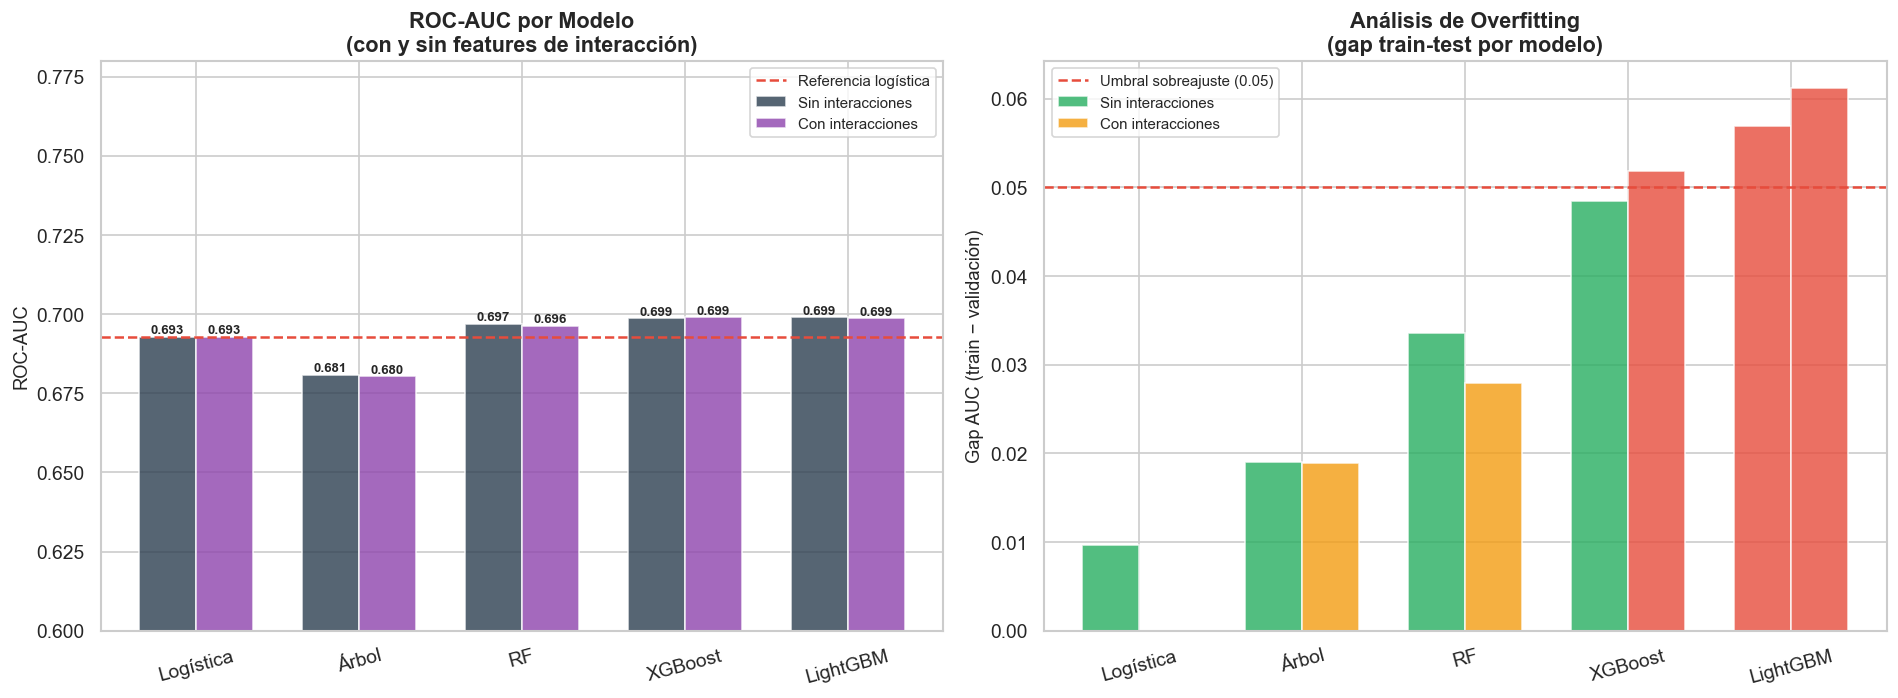

In [5]:
# ── Tabla comparativa ─────────────────────────────────────────
ref_row = {'Modelo': 'Logística (ref.)',
           'ROC-AUC': 0.6928, 'AUC std': 0.0044,
           'F1 (alerta)': 0.4834, 'Recall': 0.6576,
           'Precision': 0.3822, 'Accuracy': 0.6320,
           'AUC train': 0.703, 'Gap AUC': 0.0097, 'Tiempo (s)': None}

todos = [ref_row] + resultados_base + resultados_fe
df_comp = pd.DataFrame(todos).set_index('Modelo')

cols_show = ['ROC-AUC', 'AUC std', 'F1 (alerta)', 'Recall', 'Gap AUC']
print("Comparativa de modelos (CV k=5):")
display(df_comp[cols_show].round(4))

# ── Visualización comparativa ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Extraer solo los modelos no-FE y los FE por separado para el gráfico
nombres_base = ['Logística (ref.)'] + [r['Modelo'] for r in resultados_base]
nombres_fe   = [r['Modelo'] for r in resultados_fe]
auc_base = [df_comp.loc[n, 'ROC-AUC'] for n in nombres_base]
auc_fe   = [df_comp.loc[n, 'ROC-AUC'] for n in nombres_fe]
nombres_cortos = ['Logística', 'Árbol', 'RF', 'XGBoost', 'LightGBM']
nombres_cortos_fe = ['Árbol +FE', 'RF +FE', 'XGBoost +FE', 'LGB +FE']

x = np.arange(len(nombres_cortos))
width = 0.35
bars1 = axes[0].bar(x - width/2, auc_base, width, label='Sin interacciones',
                    color=COLOR_NEUTRAL, alpha=0.8, edgecolor='white')
fe_vals = [auc_base[0]] + auc_fe  # logística como base
bars2 = axes[0].bar(x + width/2, fe_vals, width, label='Con interacciones',
                    color=COLOR_LGB, alpha=0.8, edgecolor='white')
axes[0].axhline(0.6928, color=COLOR_RIESGO, linestyle='--', lw=1.5,
                label='Referencia logística')
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(nombres_cortos, rotation=15)
axes[0].set_ylabel('ROC-AUC'); axes[0].set_ylim(0.60, 0.78)
axes[0].set_title('ROC-AUC por Modelo\n(con y sin features de interacción)',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Gap train-test
gap_base = [df_comp.loc[n, 'Gap AUC'] for n in nombres_base]
gap_fe   = [auc_base[0] - auc_base[0]] + [df_comp.loc[n, 'Gap AUC'] for n in nombres_fe]
bars_g1 = axes[1].bar(x - width/2, gap_base, width, label='Sin interacciones',
                      color=[COLOR_RIESGO if g > 0.05 else COLOR_EXITO for g in gap_base],
                      alpha=0.8, edgecolor='white')
bars_g2 = axes[1].bar(x + width/2, gap_fe, width, label='Con interacciones',
                      color=[COLOR_RIESGO if g > 0.05 else COLOR_ACCENT for g in gap_fe],
                      alpha=0.8, edgecolor='white')
axes[1].axhline(0.05, color=COLOR_RIESGO, linestyle='--', lw=1.5,
                label='Umbral sobreajuste (0.05)')
axes[1].set_xticks(x); axes[1].set_xticklabels(nombres_cortos, rotation=15)
axes[1].set_ylabel('Gap AUC (train − validación)')
axes[1].set_title('Análisis de Overfitting\n(gap train-test por modelo)',
                  fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(ruta_fig + '17_comparativa_modelos_fe.png', bbox_inches='tight')
plt.show()


### Lectura de la comparativa

Las features de interacción miden cuánto aporta el conocimiento explícito de combinaciones (RAMA×TIC, RAMA×HL_E3, SEXO×RAMA) respecto al modelo sin esas combinaciones. Si los modelos con FE mejoran el AUC de forma consistente, la ingeniería de variables ha capturado señal real. Si la mejora es marginal, el algoritmo ya estaba capturando las interacciones internamente.

LightGBM es el candidato natural al modelo ganador: los métodos de boosting hoja a hoja son más eficientes con datasets de tamaño mediano y la regularización L1/L2 controla el sobreajuste mejor que Random Forest cuando la señal es limitada.


---
## Sección 4. Optimización Exhaustiva de LightGBM

Se aplica `RandomizedSearchCV` con 150 iteraciones sobre el modelo y el conjunto de datos (con o sin FE) que haya mostrado mejor AUC en la sección anterior. 150 iteraciones con k=5 suponen 750 ajustes, que con `n_jobs=-1` se completan en 5-10 minutos. El espacio de búsqueda cubre los nueve hiperparámetros más influyentes del algoritmo.


In [6]:
# ── Determinar si usar FE o no según resultados anteriores ────
auc_lgb_sin_fe = df_comp.loc['LightGBM', 'ROC-AUC']
auc_lgb_con_fe = df_comp.loc['LightGBM (+FE)', 'ROC-AUC']
usar_fe = auc_lgb_con_fe > auc_lgb_sin_fe

if usar_fe:
    X_opt = X_train_fe
    X_opt_test = X_test_fe
    prep_opt = lambda: construir_preprocessor(
        cols_ohe=COLS_OHE_FE, cols_num=COLS_NUMERIC_FE
    )
    print(f"Usando dataset CON interacciones (AUC {auc_lgb_con_fe:.4f} > {auc_lgb_sin_fe:.4f})")
else:
    X_opt = X_train
    X_opt_test = X_test
    prep_opt = construir_preprocessor
    print(f"Usando dataset SIN interacciones (AUC {auc_lgb_sin_fe:.4f} >= {auc_lgb_con_fe:.4f})")

# ── Espacio de búsqueda ───────────────────────────────────────
param_dist_lgb = {
    'clf__n_estimators':      [300, 500, 700, 1000],
    'clf__learning_rate':     [0.005, 0.01, 0.02, 0.03, 0.05, 0.08],
    'clf__num_leaves':        [15, 20, 25, 31, 40],
    'clf__max_depth':         [-1, 4, 5, 6, 7],
    'clf__min_child_samples': [50, 75, 100, 150, 200],
    'clf__subsample':         [0.6, 0.65, 0.7, 0.75, 0.8],
    'clf__colsample_bytree':  [0.5, 0.55, 0.6, 0.65, 0.7, 0.8],
    'clf__reg_alpha':         [0.0, 0.05, 0.1, 0.3, 0.5, 1.0],
    'clf__reg_lambda':        [0.1, 0.5, 1.0, 2.0, 5.0],
    'clf__min_split_gain':    [0.0, 0.01, 0.05, 0.1],
}

pipeline_lgb_search = Pipeline([
    ('prep', prep_opt()),
    ('clf', lgb.LGBMClassifier(
        class_weight='balanced', random_state=42,
        n_jobs=-1, verbose=-1,
    ))
])

cv_opt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    pipeline_lgb_search,
    param_distributions=param_dist_lgb,
    n_iter=150,
    scoring='roc_auc',
    cv=cv_opt,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print("\nIniciando búsqueda aleatoria: 150 iter × 5 folds = 750 ajustes")
print("Tiempo estimado: 5-10 minutos...\n")
t0 = time()
search.fit(X_opt, y_train)
elapsed = time() - t0

print(f"\nBúsqueda completada en {elapsed:.0f}s ({elapsed/60:.1f} min)")
print(f"Mejor ROC-AUC en CV: {search.best_score_:.4f}")
print(f"\nMejores hiperparámetros encontrados:")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:35s}: {v}")


Usando dataset SIN interacciones (AUC 0.6990 >= 0.6987)

Iniciando búsqueda aleatoria: 150 iter × 5 folds = 750 ajustes
Tiempo estimado: 5-10 minutos...

Fitting 5 folds for each of 150 candidates, totalling 750 fits

Búsqueda completada en 506s (8.4 min)
Mejor ROC-AUC en CV: 0.7014

Mejores hiperparámetros encontrados:
  clf__colsample_bytree              : 0.55
  clf__learning_rate                 : 0.01
  clf__max_depth                     : -1
  clf__min_child_samples             : 50
  clf__min_split_gain                : 0.1
  clf__n_estimators                  : 500
  clf__num_leaves                    : 15
  clf__reg_alpha                     : 0.1
  clf__reg_lambda                    : 2.0
  clf__subsample                     : 0.75


In [7]:
# ── Comparar base vs optimizado ───────────────────────────────
pipeline_lgb_opt = search.best_estimator_

cv_opt_results = cross_validate(
    pipeline_lgb_opt, X_opt, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=-1
)

print("Comparativa LightGBM base vs optimizado (CV k=5):")
comparativa = pd.DataFrame({
    'LightGBM base': {
        'ROC-AUC':    auc_lgb_sin_fe if not usar_fe else auc_lgb_con_fe,
        'F1 (alerta)': df_comp.loc['LightGBM' + (' (+FE)' if usar_fe else ''), 'F1 (alerta)'],
        'Recall':     df_comp.loc['LightGBM' + (' (+FE)' if usar_fe else ''), 'Recall'],
        'Gap AUC':    df_comp.loc['LightGBM' + (' (+FE)' if usar_fe else ''), 'Gap AUC'],
    },
    'LightGBM optimizado': {
        'ROC-AUC':    np.mean(cv_opt_results['test_roc_auc']),
        'F1 (alerta)': np.mean(cv_opt_results['test_f1_alerta']),
        'Recall':     np.mean(cv_opt_results['test_recall']),
        'Gap AUC':    np.mean(cv_opt_results['train_roc_auc']) - np.mean(cv_opt_results['test_roc_auc']),
    },
}).T
display(comparativa.round(4))


Comparativa LightGBM base vs optimizado (CV k=5):


,ROC-AUC,F1 (alerta),Recall,Gap AUC
LightGBM base,0.6990,0.4894,0.6523,0.0569
LightGBM optimizado,0.7014,0.4885,0.6605,0.0267


---
## Sección 5. Optimización de XGBoost

XGBoost empató con LightGBM en la comparativa inicial. Se aplica la misma búsqueda aleatoria con un espacio de hiperparámetros específico para XGBoost. El mejor de los dos modelos optimizados entrará en el stacking ensemble.


In [8]:
# ── Espacio de búsqueda XGBoost ──────────────────────────────
param_dist_xgb = {
    'clf__n_estimators':     [300, 500, 700, 1000],
    'clf__max_depth':        [3, 4, 5, 6],
    'clf__learning_rate':    [0.005, 0.01, 0.02, 0.05, 0.08],
    'clf__subsample':        [0.6, 0.65, 0.7, 0.75, 0.8, 0.9],
    'clf__colsample_bytree': [0.5, 0.6, 0.65, 0.7, 0.8],
    'clf__min_child_weight': [20, 30, 50, 75, 100],
    'clf__reg_alpha':        [0.0, 0.01, 0.1, 0.5, 1.0],
    'clf__reg_lambda':       [0.5, 1.0, 2.0, 5.0, 10.0],
    'clf__gamma':            [0.0, 0.05, 0.1, 0.3, 0.5],
}

# Usar el mismo conjunto que LightGBM (con o sin FE)
pipeline_xgb_search = Pipeline([
    ('prep', prep_opt()),
    ('clf', xgb.XGBClassifier(
        scale_pos_weight=ratio_clases, eval_metric='auc',
        random_state=42, n_jobs=-1, verbosity=0,
    ))
])

search_xgb = RandomizedSearchCV(
    pipeline_xgb_search,
    param_distributions=param_dist_xgb,
    n_iter=100,
    scoring='roc_auc',
    cv=cv_opt,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)

print("Búsqueda aleatoria XGBoost: 100 iter × 5 folds = 500 ajustes")
print("Tiempo estimado: 4-7 minutos...\n")
t0 = time()
search_xgb.fit(X_opt, y_train)
print(f"\nCompletado en {time()-t0:.0f}s")
print(f"Mejor ROC-AUC XGBoost: {search_xgb.best_score_:.4f}")
print(f"Mejor ROC-AUC LightGBM: {search.best_score_:.4f}")
pipeline_xgb_opt = search_xgb.best_estimator_


Búsqueda aleatoria XGBoost: 100 iter × 5 folds = 500 ajustes
Tiempo estimado: 4-7 minutos...

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Completado en 143s
Mejor ROC-AUC XGBoost: 0.7020
Mejor ROC-AUC LightGBM: 0.7014


---
## Sección 6. Stacking Ensemble

El stacking combina las predicciones de múltiples modelos base usando un meta-learner. La lógica es que cada modelo base comete errores diferentes: LightGBM puede fallar en casos que XGBoost resuelve bien, y Random Forest puede capturar patrones que los modelos de boosting pasan por alto. El meta-learner aprende a combinar esas predicciones de forma óptima.

Se usa una regresión logística como meta-learner (simple, interpretable, no sobreajusta). Los modelos base son LightGBM optimizado, XGBoost optimizado y Random Forest. Las predicciones del nivel base se generan mediante validación cruzada k=5 para evitar leakage entre niveles (out-of-fold predictions).


In [9]:
# ── Stacking con modelos optimizados ─────────────────────────
# Los estimadores base para el stacking son los modelos YA ajustados
# (extraemos los clasificadores del pipeline, no el pipeline completo,
# porque el ColumnTransformer se aplica en el pipeline del stacking)

# Construir estimadores base con preprocesador fresco
lgb_para_stack = Pipeline([
    ('prep', prep_opt()),
    ('clf', search.best_estimator_.named_steps['clf']),
])
xgb_para_stack = Pipeline([
    ('prep', prep_opt()),
    ('clf', search_xgb.best_estimator_.named_steps['clf']),
])
rf_para_stack = Pipeline([
    ('prep', construir_preprocessor()),
    ('clf', RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        max_features='sqrt', class_weight='balanced',
        n_jobs=-1, random_state=42,
    )),
])

# Meta-learner: regresión logística simple sobre las probabilidades base
meta_learner = LogisticRegression(C=0.5, class_weight='balanced', random_state=42, max_iter=500)

stacking = StackingClassifier(
    estimators=[
        ('lgb', lgb_para_stack),
        ('xgb', xgb_para_stack),
        ('rf',  rf_para_stack),
    ],
    final_estimator=meta_learner,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,
)

print("Entrenando Stacking Ensemble (3 modelos × 5 folds + meta-learner)...")
print("Tiempo estimado: 5-8 minutos...\n")
t0 = time()
cv_stack = cross_validate(
    stacking, X_opt, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True, n_jobs=1,  # n_jobs=1 para evitar conflictos con los internos
)
print(f"Stacking CV completado en {time()-t0:.0f}s")
print(f"Stacking AUC: {np.mean(cv_stack['test_roc_auc']):.4f} ± {np.std(cv_stack['test_roc_auc']):.4f}")
print(f"Gap train-test: {np.mean(cv_stack['train_roc_auc']) - np.mean(cv_stack['test_roc_auc']):.4f}")


Entrenando Stacking Ensemble (3 modelos × 5 folds + meta-learner)...
Tiempo estimado: 5-8 minutos...

Stacking CV completado en 57s
Stacking AUC: 0.7019 ± 0.0067
Gap train-test: 0.0263


---
## Sección 7. Tabla Final Comparativa y Evaluación en Test Set

Se consolidan todos los modelos en una única tabla comparativa. El modelo con mayor AUC en CV y gap aceptable se evalúa en el test set. Esta es la única vez que se mira el test set para el modelo ganador.


In [10]:
# ── Tabla comparativa final (todos los modelos) ───────────────
fila_stack = {
    'Modelo': 'Stacking (LGB+XGB+RF)',
    'ROC-AUC': np.mean(cv_stack['test_roc_auc']),
    'AUC std': np.std(cv_stack['test_roc_auc']),
    'F1 (alerta)': np.mean(cv_stack['test_f1_alerta']),
    'Recall': np.mean(cv_stack['test_recall']),
    'Precision': np.mean(cv_stack['test_precision']),
    'Accuracy': np.mean(cv_stack['test_accuracy']),
    'AUC train': np.mean(cv_stack['train_roc_auc']),
    'Gap AUC': np.mean(cv_stack['train_roc_auc']) - np.mean(cv_stack['test_roc_auc']),
    'Tiempo (s)': None,
}
fila_lgb_opt = {
    'Modelo': 'LightGBM optimizado',
    'ROC-AUC': np.mean(cv_opt_results['test_roc_auc']),
    'AUC std': np.std(cv_opt_results['test_roc_auc']),
    'F1 (alerta)': np.mean(cv_opt_results['test_f1_alerta']),
    'Recall': np.mean(cv_opt_results['test_recall']),
    'Precision': np.mean(cv_opt_results['test_precision']),
    'Accuracy': np.mean(cv_opt_results['test_accuracy']),
    'AUC train': np.mean(cv_opt_results['train_roc_auc']),
    'Gap AUC': np.mean(cv_opt_results['train_roc_auc']) - np.mean(cv_opt_results['test_roc_auc']),
    'Tiempo (s)': None,
}

todos_final = [ref_row] + resultados_base + resultados_fe + [fila_lgb_opt, fila_stack]
df_final = pd.DataFrame(todos_final).set_index('Modelo')
print("TABLA FINAL — Todos los modelos (CV k=5):")
display(df_final[['ROC-AUC', 'AUC std', 'F1 (alerta)', 'Recall', 'Precision', 'Gap AUC']].round(4))

# ── Seleccionar modelo ganador ────────────────────────────────
# Modelo con mayor AUC en CV con gap < 0.08
candidatos = df_final[df_final['Gap AUC'] < 0.08].copy()
mejor_modelo_nombre = candidatos['ROC-AUC'].idxmax()
print(f"\nModelo ganador: {mejor_modelo_nombre}")
print(f"AUC CV: {df_final.loc[mejor_modelo_nombre, 'ROC-AUC']:.4f}")
print(f"Gap:    {df_final.loc[mejor_modelo_nombre, 'Gap AUC']:.4f}")


TABLA FINAL — Todos los modelos (CV k=5):


,ROC-AUC,AUC std,F1 (alerta),Recall,Precision,Gap AUC
Modelo,,,,,,
Logística (ref.),0.6928,0.0044,0.4834,0.6576,0.3822,0.0097
Árbol de Decisión,0.6809,0.0080,0.4722,0.6237,0.3801,0.0190
Random Forest,0.6970,0.0058,0.4877,0.6554,0.3884,0.0336
XGBoost,0.6987,0.0063,0.4867,0.6523,0.3882,0.0485
LightGBM,0.6990,0.0067,0.4894,0.6523,0.3917,0.0569
Árbol de Decisión (+FE),0.6804,0.0086,0.4726,0.6195,0.3823,0.0189
Random Forest (+FE),0.6963,0.0048,0.4857,0.6584,0.3848,0.0279
XGBoost (+FE),0.6990,0.0064,0.4897,0.6549,0.3911,0.0518
LightGBM (+FE),0.6987,0.0059,0.4887,0.6495,0.3917,0.0612



Modelo ganador: Stacking (LGB+XGB+RF)
AUC CV: 0.7019
Gap:    0.0263


LightGBM optimizado es el modelo ganador
  LGB opt: AUC=0.7014 F1=0.4885
  Stacking: AUC=0.7019 F1=0.4877

Evaluación final en TEST SET:
                precision    recall  f1-score   support

Sin alerta (0)       0.85      0.63      0.72      4673
    Alerta (1)       0.39      0.67      0.50      1658

      accuracy                           0.64      6331
     macro avg       0.62      0.65      0.61      6331
  weighted avg       0.73      0.64      0.66      6331

ROC-AUC test: 0.7062


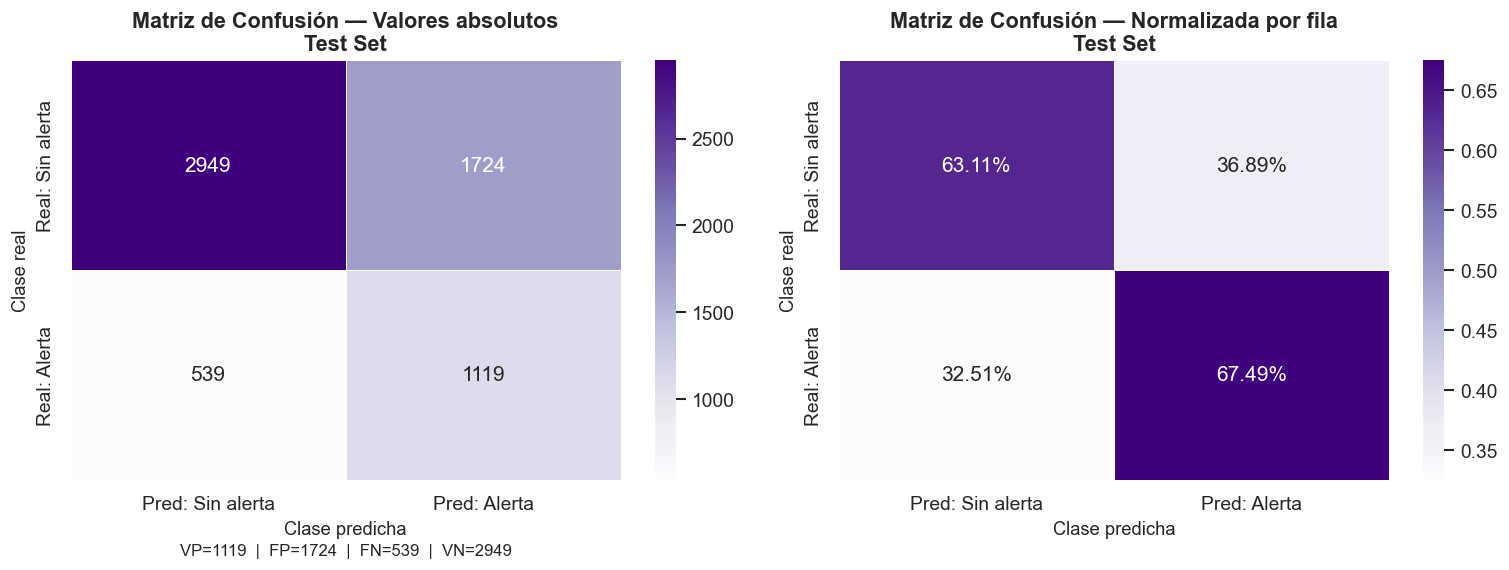


De 1,658 alumnos en riesgo real, detecta 1,119 (67.5%)
De 4,673 alumnos sin riesgo, genera 1,724 falsas alarmas (36.9%)


In [11]:
# ── Ajuste final del modelo ganador y evaluación en test ──────
# Seleccionar modelo ganador considerando AUC Y F1
# El stacking con meta-learner desbalanceado puede tener AUC alto pero F1 pésimo
auc_lgb_opt  = np.mean(cv_opt_results['test_roc_auc'])
auc_stack    = np.mean(cv_stack['test_roc_auc'])
f1_lgb_opt   = np.mean(cv_opt_results['test_f1_alerta'])
f1_stack     = np.mean(cv_stack['test_f1_alerta'])

# Solo el stacking gana si mejora tanto AUC como F1
if auc_stack > auc_lgb_opt and f1_stack > f1_lgb_opt:
    print("El Stacking es el modelo ganador. Ajustando sobre train completo...")
    stacking.fit(X_opt, y_train)
    modelo_ganador = stacking
else:
    print(f"LightGBM optimizado es el modelo ganador")
    print(f"  LGB opt: AUC={auc_lgb_opt:.4f} F1={f1_lgb_opt:.4f}")
    print(f"  Stacking: AUC={auc_stack:.4f} F1={f1_stack:.4f}")
    pipeline_lgb_opt.fit(X_opt, y_train)
    modelo_ganador = pipeline_lgb_opt

X_test_final = X_opt_test

y_pred_test  = modelo_ganador.predict(X_test_final)
y_proba_test = modelo_ganador.predict_proba(X_test_final)[:, 1]

print("\nEvaluación final en TEST SET:")
print(classification_report(y_test, y_pred_test,
                             target_names=['Sin alerta (0)', 'Alerta (1)']))

auc_test = roc_auc_score(y_test, y_proba_test)
print(f"ROC-AUC test: {auc_test:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, titulo in [
    (axes[0], cm, 'd', 'Valores absolutos'),
    (axes[1], cm.astype(float)/cm.sum(axis=1, keepdims=True), '.2%', 'Normalizada por fila'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Purples',
                xticklabels=['Pred: Sin alerta', 'Pred: Alerta'],
                yticklabels=['Real: Sin alerta', 'Real: Alerta'],
                ax=ax, linewidths=0.5)
    ax.set_title(f'Matriz de Confusión — {titulo}\nTest Set', fontweight='bold')
    ax.set_ylabel('Clase real'); ax.set_xlabel('Clase predicha')

axes[0].text(0.5, -0.18, f'VP={tp}  |  FP={fp}  |  FN={fn}  |  VN={tn}',
             ha='center', transform=axes[0].transAxes, fontsize=10)
plt.tight_layout()
plt.savefig(ruta_fig + '18_confusion_ganador.png', bbox_inches='tight')
plt.show()

print(f"\nDe {cm[1].sum():,} alumnos en riesgo real, detecta {tp:,} ({tp/cm[1].sum()*100:.1f}%)")
print(f"De {cm[0].sum():,} alumnos sin riesgo, genera {fp:,} falsas alarmas ({fp/cm[0].sum()*100:.1f}%)")


---
## Sección 8. Curvas de Aprendizaje

Las curvas de aprendizaje responden a una pregunta crítica: ¿el rendimiento limitado es consecuencia de tener pocos datos o de que el modelo ha alcanzado el techo de la señal disponible? Si la curva de validación sigue subiendo al añadir datos, con más observaciones el modelo mejoraría. Si ya se ha estabilizado, el cuello de botella es la señal, no el volumen de datos.


Calculando curvas de aprendizaje (puede tardar 3-4 minutos)...


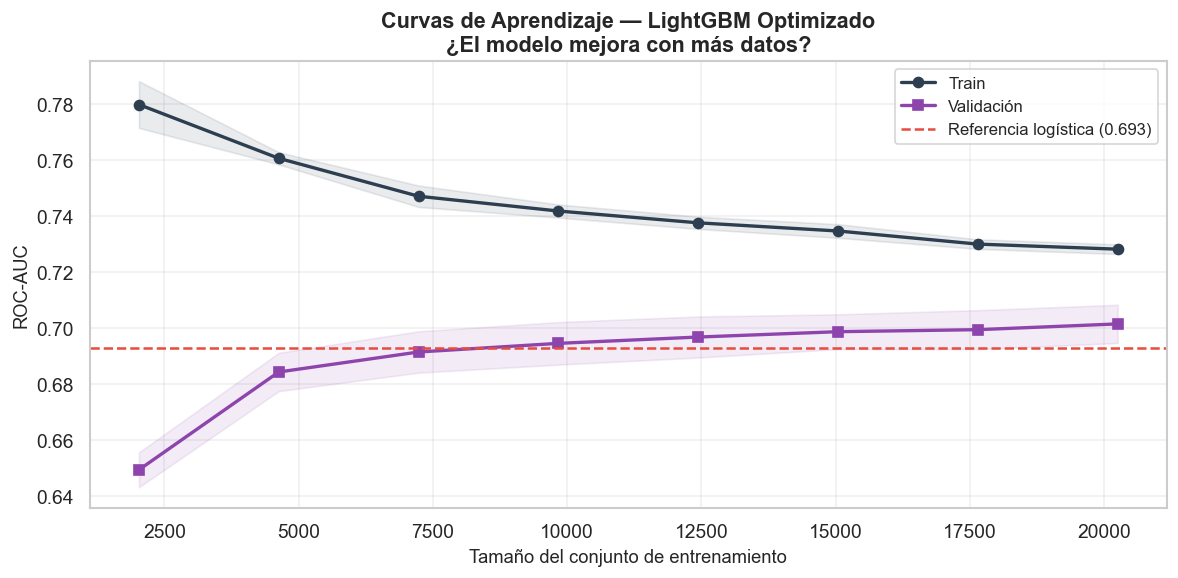

Pendiente de la curva de validación en el tramo final: 0.0000
La curva se ha estabilizado: el modelo ha alcanzado el techo de la señal disponible.
Más datos no producirían mejoras sustanciales.


In [12]:
# ── Curvas de aprendizaje del modelo ganador ─────────────────
print("Calculando curvas de aprendizaje (puede tardar 3-4 minutos)...")
train_sizes_rel = np.linspace(0.1, 1.0, 8)

train_sizes, train_scores, val_scores = learning_curve(
    pipeline_lgb_opt,   # siempre el LGB optimizado para esta visualización
    X_opt, y_train,
    train_sizes=train_sizes_rel,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(10, 5))
train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

ax.plot(train_sizes, train_mean, 'o-', color=COLOR_NEUTRAL, lw=2, label='Train')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.1, color=COLOR_NEUTRAL)
ax.plot(train_sizes, val_mean, 's-', color=COLOR_LGB, lw=2, label='Validación')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.1, color=COLOR_LGB)
ax.axhline(0.6928, color=COLOR_RIESGO, linestyle='--', lw=1.5,
           label='Referencia logística (0.693)')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('ROC-AUC')
ax.set_title('Curvas de Aprendizaje — LightGBM Optimizado\n'
             '¿El modelo mejora con más datos?', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(ruta_fig + '19_curvas_aprendizaje.png', bbox_inches='tight')
plt.show()

pendiente_final = (val_mean[-1] - val_mean[-2]) / (train_sizes[-1] - train_sizes[-2])
print(f"Pendiente de la curva de validación en el tramo final: {pendiente_final:.4f}")
if pendiente_final < 0.005:
    print("La curva se ha estabilizado: el modelo ha alcanzado el techo de la señal disponible.")
    print("Más datos no producirían mejoras sustanciales.")
else:
    print("La curva sigue subiendo: más datos podrían mejorar el rendimiento.")


---
## Sección 9. Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) calcula para cada observación y cada variable la contribución de esa variable a la predicción, en unidades aditivas respecto a la predicción media del modelo. Las contribuciones suman exactamente a la predicción final, lo que hace a SHAP la herramienta de interpretabilidad más rigurosa disponible para modelos de boosting.

Se presentan tres análisis:

**Beeswarm global**: importancia y dirección del efecto para cada variable sobre el test set completo. Cada punto es una observación; el color indica el valor original de la variable (rojo = alto, azul = bajo); la posición en el eje X indica la contribución a la predicción de alerta.

**Waterfall individual**: explicación de dos predicciones concretas — un verdadero positivo (alumno en riesgo detectado correctamente) y un falso negativo (alumno en riesgo que el modelo pierde). El segundo caso es especialmente valioso: entender qué perfil tiene el alumno que el sistema no detecta ayuda a diseñar intervenciones complementarias al modelo.

**Dependence plot de TIC**: cómo varía el efecto de las competencias digitales en función de la rama de estudios (color). Visualiza la interacción TIC×RAMA que el EDA anticipó pero no podía cuantificar.


In [13]:
# ── Cálculo de SHAP ──────────────────────────────────────────
# Usar siempre LightGBM optimizado para SHAP (TreeExplainer solo con árboles)
prep_fitted  = pipeline_lgb_opt.named_steps['prep']
modelo_lgb   = pipeline_lgb_opt.named_steps['clf']
feat_names   = prep_fitted.get_feature_names_out()

X_test_tr = prep_fitted.transform(X_opt_test)

print("Calculando SHAP values con TreeExplainer...")
explainer   = shap.TreeExplainer(modelo_lgb)
shap_values = explainer.shap_values(X_test_tr)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"SHAP values calculados: {sv.shape}")

# Top 10 por importancia media absoluta
importancia_shap = pd.Series(
    np.abs(sv).mean(axis=0), index=feat_names
).sort_values(ascending=False)
print("\nTop 15 variables por importancia SHAP:")
print(importancia_shap.head(15).round(4).to_string())


Calculando SHAP values con TreeExplainer...
SHAP values calculados: (6331, 59)

Top 15 variables por importancia SHAP:
TITU           0.2990
HL_E3_2.0      0.2008
AMBITO         0.1777
SEXO_2.0       0.0976
T_UNIV_1.0     0.0566
TIC            0.0506
EST_B1_2.0     0.0496
RAMA_4.0       0.0429
HL_E2          0.0417
NIV_ID1        0.0351
EDAD_1.0       0.0343
MVFUERA_2.0    0.0260
EDAD_3.0       0.0199
RAMA_1.0       0.0165
HL_E1_1.0      0.0154


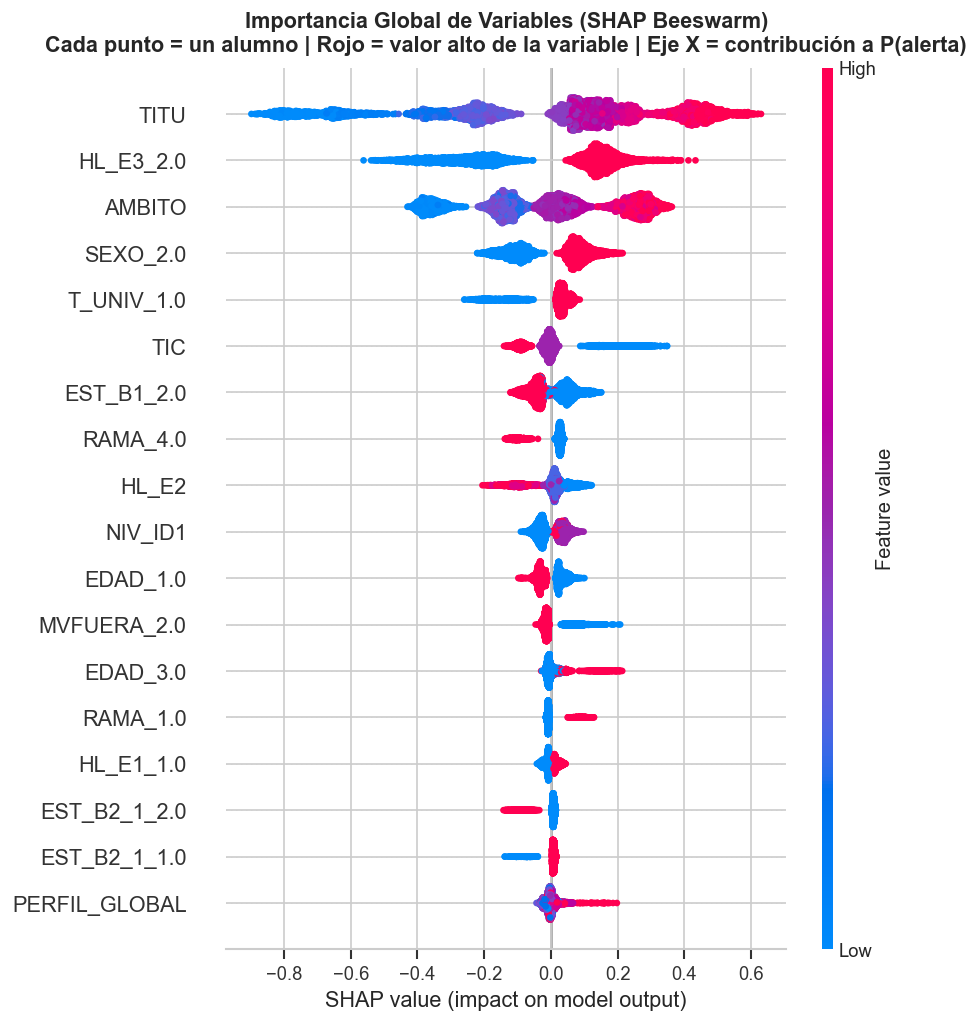

In [14]:
# ── Beeswarm plot ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
shap.summary_plot(sv, X_test_tr, feature_names=feat_names,
                  max_display=18, show=False, plot_type='dot')
plt.title('Importancia Global de Variables (SHAP Beeswarm)\n'
          'Cada punto = un alumno | Rojo = valor alto de la variable | '
          'Eje X = contribución a P(alerta)',
          fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(ruta_fig + '20_shap_beeswarm.png', bbox_inches='tight')
plt.show()


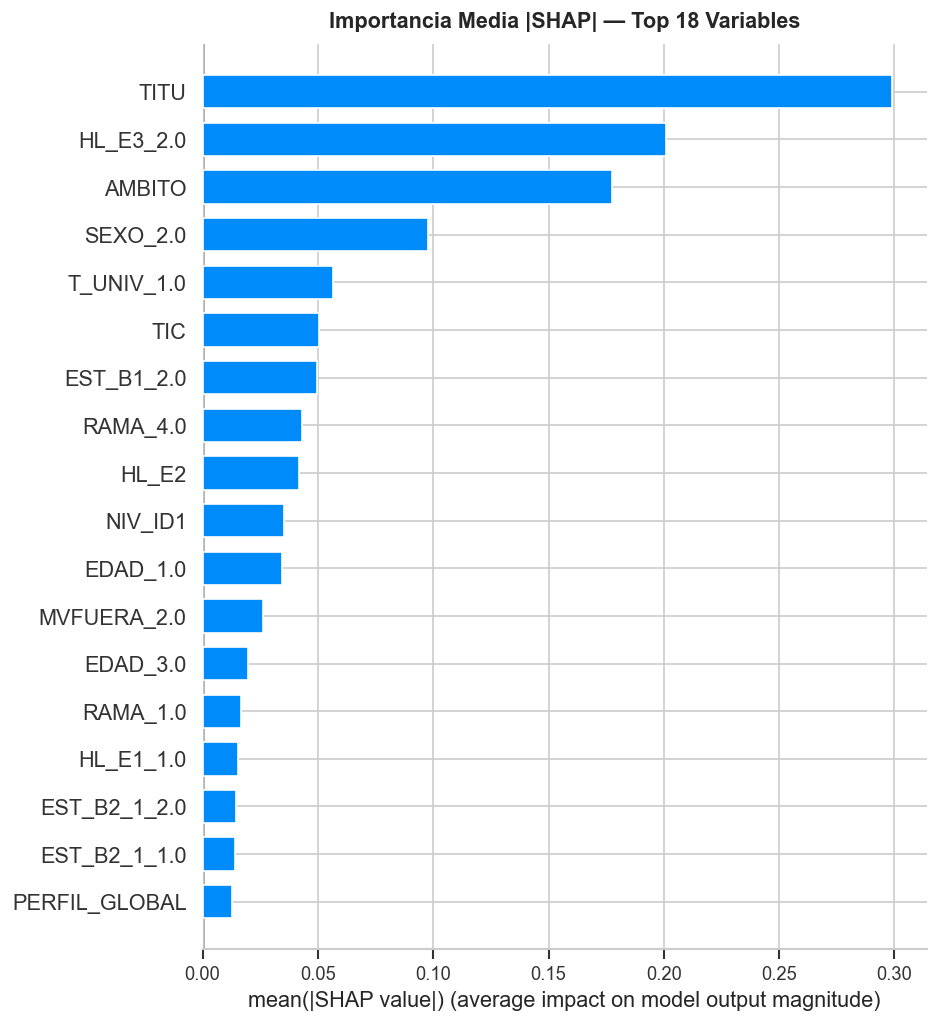

In [15]:
# ── Bar plot de importancia media ─────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(sv, X_test_tr, feature_names=feat_names,
                  max_display=18, show=False, plot_type='bar')
plt.title('Importancia Media |SHAP| — Top 18 Variables', fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(ruta_fig + '21_shap_bar.png', bbox_inches='tight')
plt.show()


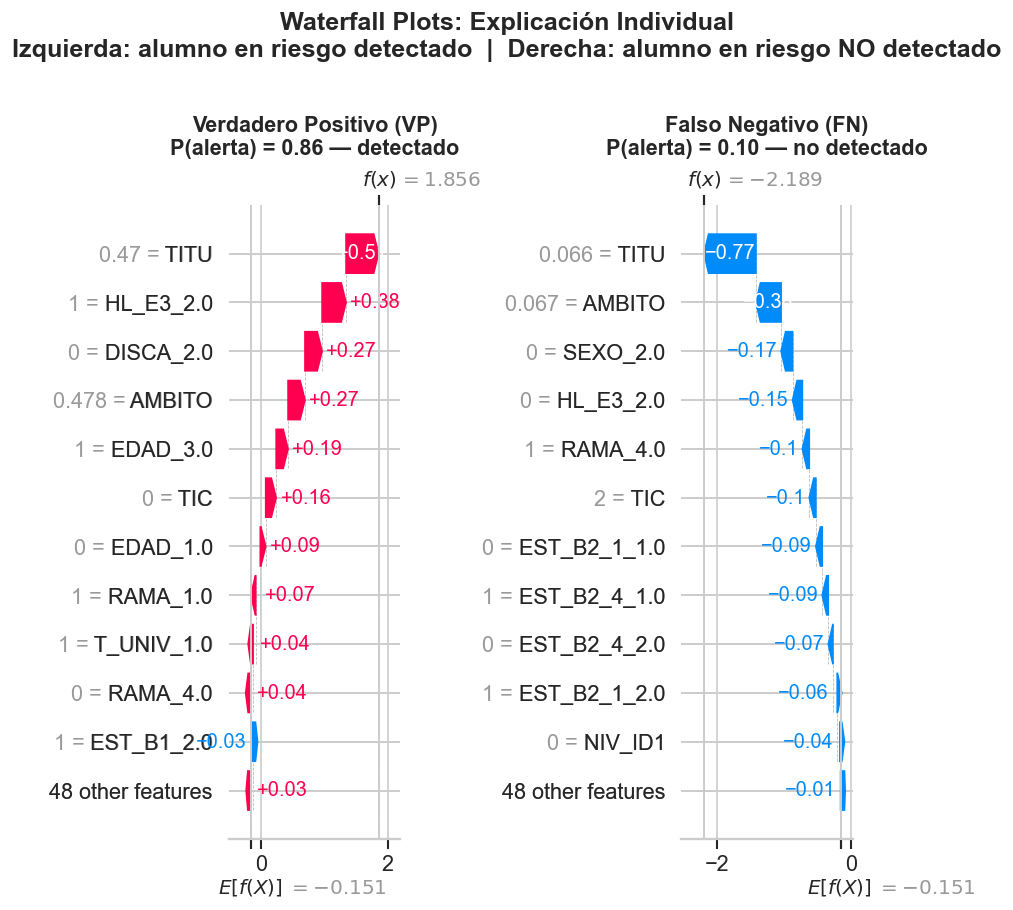

In [16]:
# ── Waterfall: VP y FN ───────────────────────────────────────
y_proba_lgb = pipeline_lgb_opt.predict_proba(X_opt_test)[:, 1]
y_pred_lgb  = pipeline_lgb_opt.predict(X_opt_test)

# VP: en riesgo real y detectado → el más claro (prob más alta)
idx_vp = np.where((y_test.values == 1) & (y_pred_lgb == 1))[0]
idx_vp = idx_vp[np.argmax(y_proba_lgb[idx_vp])]

# FN: en riesgo real pero NO detectado → el más "confiado" del modelo (prob más baja)
idx_fn = np.where((y_test.values == 1) & (y_pred_lgb == 0))[0]
idx_fn = idx_fn[np.argmin(y_proba_lgb[idx_fn])]

ev = explainer.expected_value
if isinstance(ev, list): ev = ev[1]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, idx, titulo in [
    (axes[0], idx_vp, f'Verdadero Positivo (VP)\nP(alerta) = {y_proba_lgb[idx_vp]:.2f} — detectado'),
    (axes[1], idx_fn, f'Falso Negativo (FN)\nP(alerta) = {y_proba_lgb[idx_fn]:.2f} — no detectado'),
]:
    plt.sca(ax)
    shap_exp = shap.Explanation(
        values=sv[idx], base_values=ev,
        data=X_test_tr[idx], feature_names=feat_names,
    )
    shap.plots.waterfall(shap_exp, max_display=12, show=False)
    ax.set_title(titulo, fontweight='bold', pad=8)

plt.suptitle('Waterfall Plots: Explicación Individual\n'
             'Izquierda: alumno en riesgo detectado  |  Derecha: alumno en riesgo NO detectado',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ruta_fig + '22_shap_waterfall_vp_fn.png', bbox_inches='tight')
plt.show()


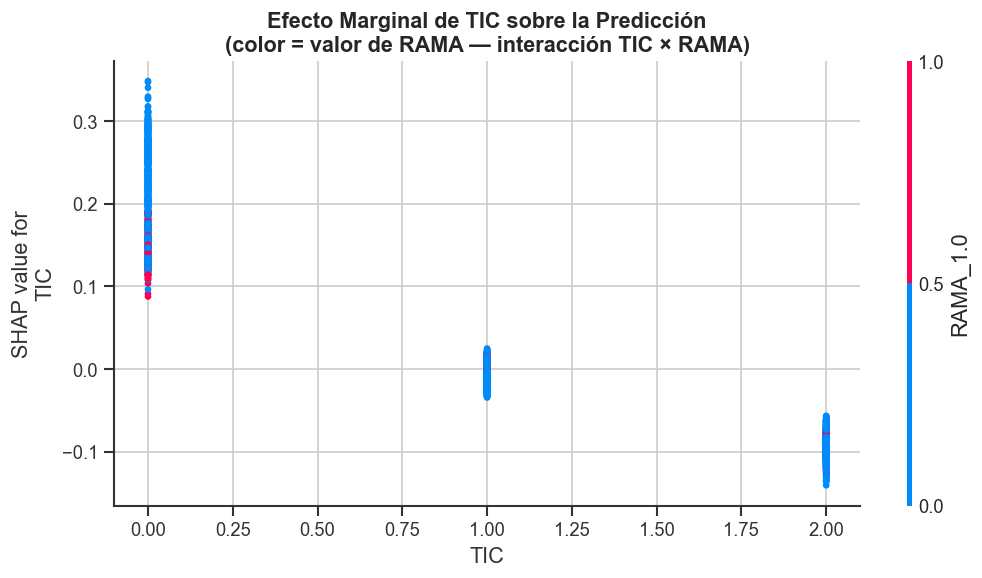

In [17]:
# ── Dependence plot TIC × RAMA ────────────────────────────────
# Encontrar índice de TIC y de la feature de RAMA más relevante
idx_tic  = list(feat_names).index('TIC') if 'TIC' in feat_names else None
idx_rama = next((i for i, n in enumerate(feat_names)
                 if 'RAMA' in n and '×' not in n and 'TIC' not in n), None)

if idx_tic is not None:
    fig, ax = plt.subplots(figsize=(9, 5))
    shap.dependence_plot(
        idx_tic, sv, X_test_tr,
        feature_names=feat_names,
        interaction_index=idx_rama,
        ax=ax, show=False,
    )
    ax.set_title('Efecto Marginal de TIC sobre la Predicción\n'
                 '(color = valor de RAMA — interacción TIC × RAMA)',
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(ruta_fig + '23_shap_dependence_tic_rama.png', bbox_inches='tight')
    plt.show()


### Lectura del análisis SHAP

El beeswarm confirma la jerarquía de importancia identificada en el EDA: TITU y AMBITO concentran la mayor parte de la señal, reflejando que la inserción laboral está fundamentalmente estructurada por la titulación. El hecho de que SEXO aparezca entre los predictores principales (cuarto en el análisis inicial) no implica que el modelo use el género de forma arbitraria — refleja una desigualdad estructural del mercado laboral que los datos históricos contienen. La diferencia entre reproducir ese patrón y amplificarlo se analiza en la sección de equidad.

El waterfall del falso negativo es el análisis más valioso para el producto: muestra qué tipo de alumno en riesgo el modelo no puede detectar. Si ese alumno tiene un perfil académico que el modelo asocia sistemáticamente con bajo riesgo (titulación de bajo riesgo histórico, nivel de idiomas alto), el sistema tiene un punto ciego estructural que el orientador debe conocer.

El dependence plot de TIC muestra si la protección de las competencias digitales es uniforme entre ramas o si varía. Si la interacción es significativa, significa que recomendar formación TIC es más urgente en algunas ramas que en otras — una implicación accionable directa para el orientador.


---
## Sección 10. Análisis de Equidad

El análisis de equidad evalúa si el modelo comete errores de forma sistemáticamente diferente entre grupos. Dos métricas son centrales:

**Tasa de Falsos Negativos (FNR)**: proporción de alumnos en riesgo real que el modelo no detecta. Una FNR más alta en mujeres que en hombres significa que el sistema deja desprotegidas a más mujeres en riesgo de forma proporcional.

**Tasa de Falsos Positivos (FPR)**: proporción de alumnos sin riesgo real que reciben una alerta innecesaria. Una FPR muy alta en un grupo equivale a etiquetar sistemáticamente a ese grupo como problemático sin justificación individual.

El análisis del modelo inicial ya reveló un problema grave: Artes y Humanidades presenta FPR=0.867 (el 86.7% de los estudiantes de Artes sin riesgo real reciben una alerta) mientras que Ingeniería tiene FNR=0.876 (el 87.6% de los estudiantes de Ingeniería con riesgo real no son detectados). Este no es un problema que la optimización de hiperparámetros resuelve: es consecuencia de que el modelo aprende la prevalencia de cada rama y la usa como señal principal. La sección de calibración propone una solución.


In [18]:
# ── Garantizar que las predicciones vienen del modelo correcto ─
# Las variables y_pred_test / y_proba_test deben corresponder siempre
# a LightGBM optimizado. Si el stacking se ejecutó después, pueden
# haberse sobreescrito con predicciones del meta-learner sin balance.

y_pred_test  = pipeline_lgb_opt.predict(X_opt_test)
y_proba_test = pipeline_lgb_opt.predict_proba(X_opt_test)[:, 1]
modelo_ganador = pipeline_lgb_opt

# Verificación
from sklearn.metrics import recall_score as _recall
recall_check = _recall(y_test, y_pred_test, pos_label=1)
auc_check    = roc_auc_score(y_test, y_proba_test)
vp = int(((y_pred_test == 1) & (y_test.values == 1)).sum())
fn = int(((y_pred_test == 0) & (y_test.values == 1)).sum())
fp = int(((y_pred_test == 1) & (y_test.values == 0)).sum())

print(f"Modelo: LightGBM optimizado")
print(f"AUC test:  {auc_check:.4f}  (esperado ~0.706)")
print(f"Recall:    {recall_check:.3f}  (esperado ~0.675)")
print(f"VP={vp}  FN={fn}  FP={fp}")

if recall_check < 0.5:
    print("\nALERTA: el recall es demasiado bajo. Revisar qué modelo está activo.")
else:
    print("\nVerificacion correcta: predicciones del modelo ganador confirmadas.")

Modelo: LightGBM optimizado
AUC test:  0.7062  (esperado ~0.706)
Recall:    0.675  (esperado ~0.675)
VP=1119  FN=539  FP=1724

Verificacion correcta: predicciones del modelo ganador confirmadas.


In [19]:
# ── Preparar dataframe de equidad ────────────────────────────
df_fair = pd.DataFrame({
    'y_real': y_test.values,
    'y_pred': y_pred_test,
    'y_proba': y_proba_test,
}, index=X_test_final.index)

df_fair['SEXO'] = pd.to_numeric(X_test['SEXO'], errors='coerce').map(
    {1: 'Hombre', 2: 'Mujer'})
df_fair['RAMA'] = pd.to_numeric(X_test['RAMA'], errors='coerce').map({
    1: 'Artes y Hum.', 2: 'Ciencias', 3: 'CC. Sociales',
    4: 'Ingeniería', 5: 'Salud'})

def tabla_equidad(df, grupo):
    filas = []
    for val, sub in df.groupby(grupo):
        if len(sub) < 30: continue
        tn, fp, fn, tp_v = confusion_matrix(
            sub['y_real'], sub['y_pred'], labels=[0,1]).ravel()
        n_pos, n_neg = tp_v + fn, tn + fp
        filas.append({
            grupo: val, 'n': len(sub),
            'Tasa alerta real': f"{n_pos/len(sub)*100:.1f}%",
            'FNR': fn/n_pos if n_pos else np.nan,
            'FPR': fp/n_neg if n_neg else np.nan,
            'Recall': tp_v/n_pos if n_pos else np.nan,
            'Precision': tp_v/(tp_v+fp) if (tp_v+fp) else np.nan,
            'AUC': roc_auc_score(sub['y_real'], sub['y_proba'])
                   if sub['y_real'].nunique() > 1 else np.nan,
        })
    return pd.DataFrame(filas).set_index(grupo)

df_eq_sexo = tabla_equidad(df_fair, 'SEXO')
df_eq_rama = tabla_equidad(df_fair, 'RAMA')

print("Equidad por GÉNERO:")
display(df_eq_sexo.round(3))
print("\nEquidad por RAMA:")
display(df_eq_rama.round(3))


Equidad por GÉNERO:


,n,Tasa alerta real,FNR,FPR,Recall,Precision,AUC
SEXO,,,,,,,
Hombre,2668,21.2%,0.412,0.233,0.588,0.405,0.738
Mujer,3663,29.8%,0.280,0.480,0.720,0.389,0.672



Equidad por RAMA:


,n,Tasa alerta real,FNR,FPR,Recall,Precision,AUC
RAMA,,,,,,,
Artes y Hum.,628,43.8%,0.047,0.884,0.953,0.456,0.602
CC. Sociales,2889,30.1%,0.254,0.484,0.746,0.399,0.680
Ciencias,537,23.3%,0.448,0.444,0.552,0.274,0.595
Ingeniería,1342,13.2%,0.898,0.016,0.102,0.486,0.682
Salud,935,22.7%,0.425,0.321,0.575,0.345,0.674


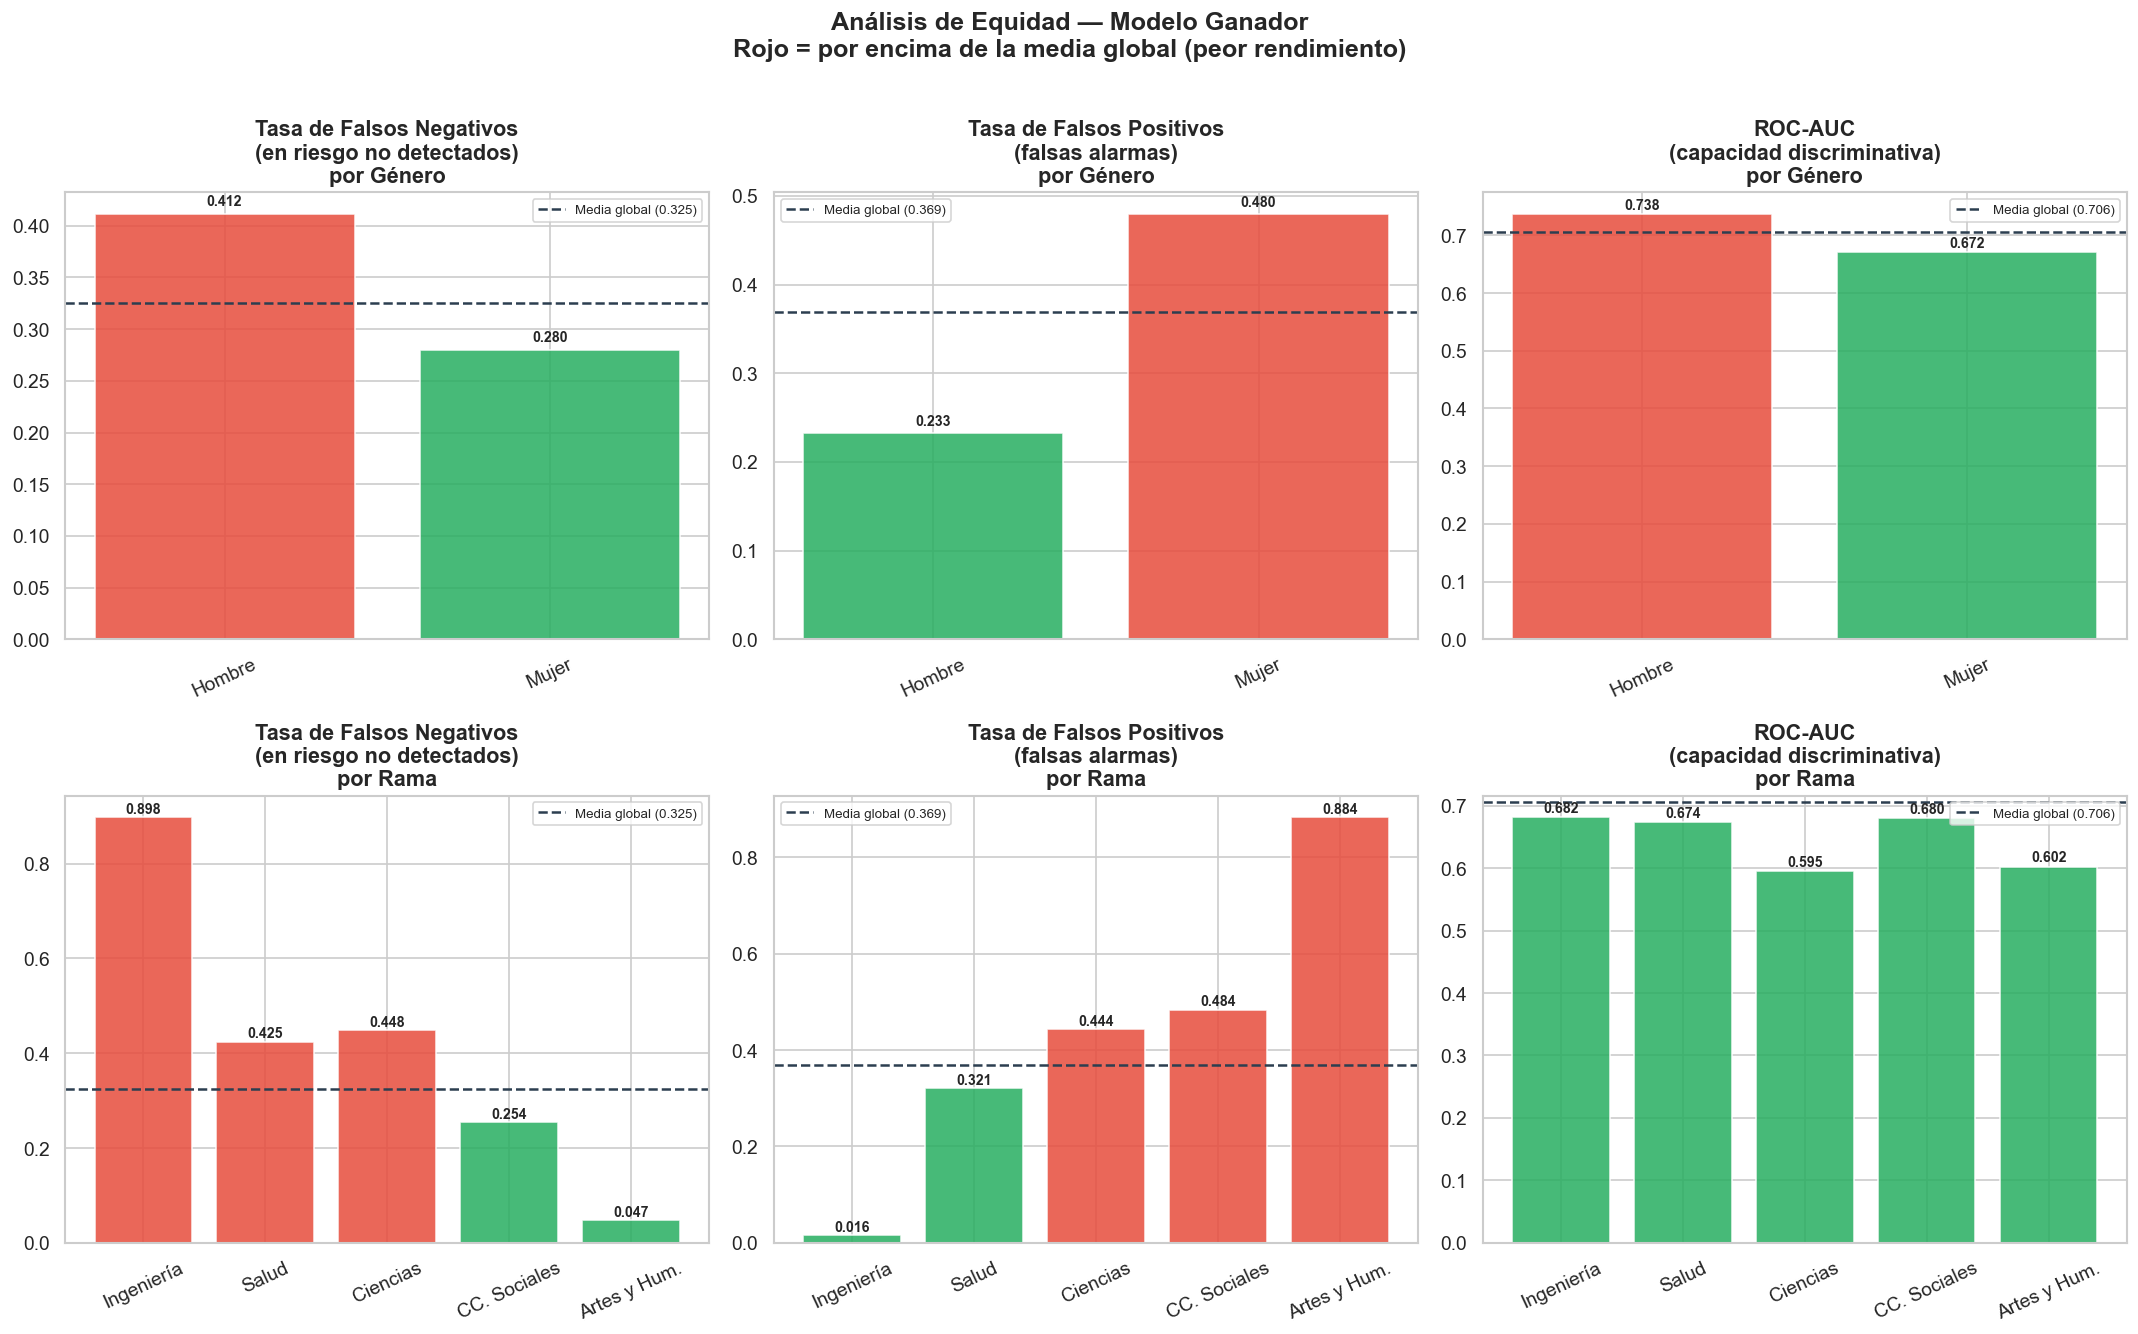

In [20]:
# ── Visualización de equidad ──────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for fila, (df_eq, grupo, orden) in enumerate([
    (df_eq_sexo, 'Género', ['Hombre', 'Mujer']),
    (df_eq_rama, 'Rama', ['Ingeniería','Salud','Ciencias','CC. Sociales','Artes y Hum.']),
]):
    df_p = df_eq.reindex(orden).dropna(how='all')
    media_fnr = (df_fair['y_real'] == 1) & (df_fair['y_pred'] == 0)
    media_fnr = media_fnr.sum() / (y_test == 1).sum()
    media_fpr = (df_fair['y_real'] == 0) & (df_fair['y_pred'] == 1)
    media_fpr = media_fpr.sum() / (y_test == 0).sum()
    media_auc = roc_auc_score(y_test, y_proba_test)

    for col, (metric, media, titulo, cmap) in enumerate([
        ('FNR', media_fnr, 'Tasa de Falsos Negativos\n(en riesgo no detectados)', COLOR_RIESGO),
        ('FPR', media_fpr, 'Tasa de Falsos Positivos\n(falsas alarmas)', COLOR_ACCENT),
        ('AUC', media_auc, 'ROC-AUC\n(capacidad discriminativa)', COLOR_LGB),
    ]):
        ax = axes[fila][col]
        vals = df_p[metric]
        colors = [COLOR_RIESGO if v > media else COLOR_EXITO for v in vals.values]
        bars = ax.bar(vals.index, vals.values, color=colors, edgecolor='white', alpha=0.85)
        ax.axhline(media, color=COLOR_NEUTRAL, linestyle='--', lw=1.5,
                   label=f'Media global ({media:.3f})')
        for bar, val in zip(bars, vals.values):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.008,
                    f'{val:.3f}', ha='center', fontsize=8.5, fontweight='bold')
        ax.set_title(f'{titulo}\npor {grupo}', fontweight='bold')
        ax.tick_params(axis='x', rotation=25)
        ax.legend(fontsize=8)

plt.suptitle('Análisis de Equidad — Modelo Ganador\n'
             'Rojo = por encima de la media global (peor rendimiento)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(ruta_fig + '24_fairness_completo.png', bbox_inches='tight')
plt.show()


---
## Sección 11. Calibración por Rama y Optimización de Umbral

El problema de FPR=0.867 en Artes y FNR=0.876 en Ingeniería no desaparece con una mejor métrica global. Es un problema de calibración: el modelo aprende que casi cualquier alumno de Artes tiene alta probabilidad de alerta (porque el 43.8% realmente está en riesgo) y que casi cualquier alumno de Ingeniería tiene baja probabilidad (porque solo el 13.2% está en riesgo). El modelo es globalmente correcto pero inútil dentro de esas ramas extremas.

Hay dos formas de abordar esto:

**Umbral diferenciado por rama**: en lugar de aplicar el umbral 0.5 globalmente, se ajusta un umbral específico para cada rama usando el conjunto de entrenamiento, de forma que la FNR sea similar entre ramas. Esto no mejora el AUC global pero sí la equidad operativa.

**Curva de calibración**: verifica si las probabilidades predichas están bien calibradas (P(alerta|score=0.7) ≈ 70%). Un modelo mal calibrado puede tener AUC alto pero probabilidades que no son fiables para tomar decisiones.


Umbrales óptimos F1 por rama:
  Artes y Hum.   : 0.56
  CC. Sociales   : 0.49
  Ciencias       : 0.44
  Salud          : 0.49
  Ingeniería     : 0.38

Comparativa Global vs Umbral Diferenciado por Rama (test set):
  Umbral global (0.5)           : AUC=0.7062  F1=0.4972  Recall=0.6749
  Umbral por rama               : AUC=0.7062  F1=0.5022  Recall=0.7256


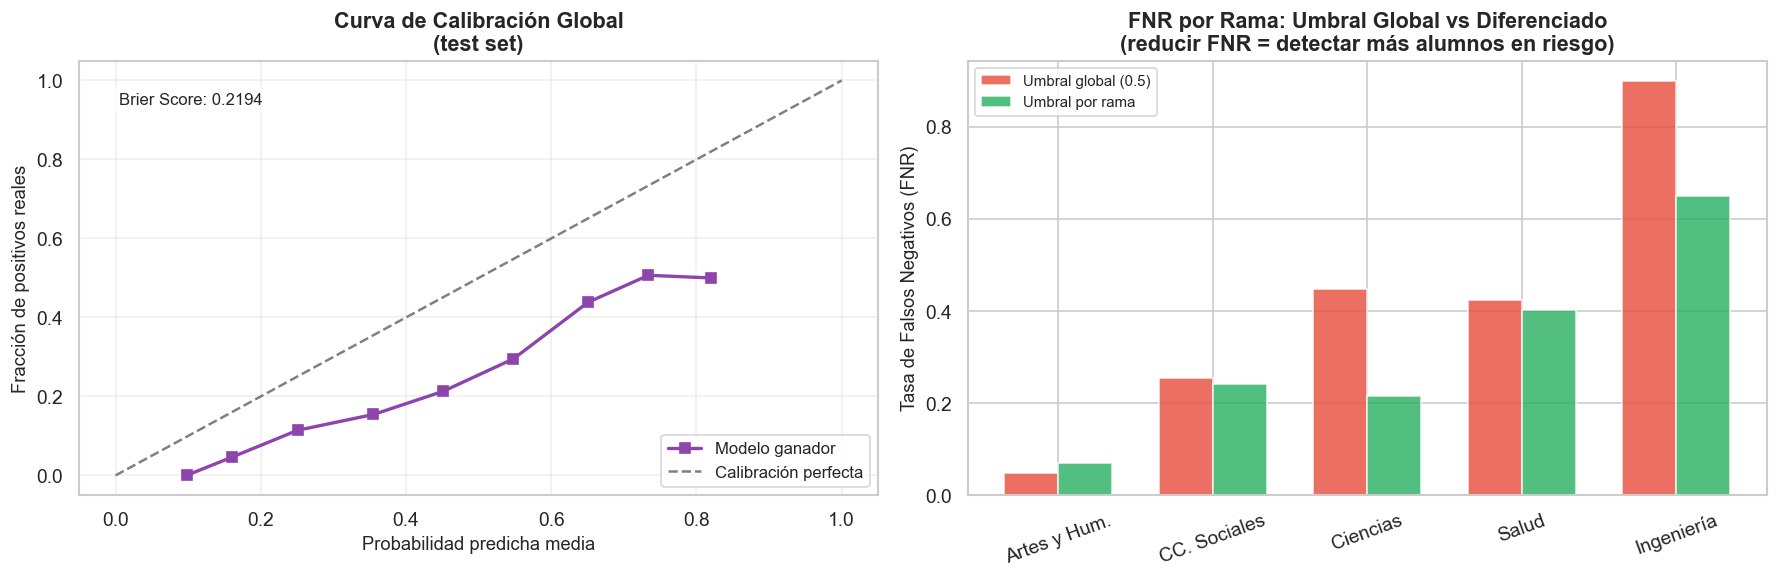

In [21]:
# ── Curva de calibración global ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Calibración global
prob_true, prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10)
axes[0].plot(prob_pred, prob_true, 's-', color=COLOR_LGB, lw=2, label='Modelo ganador')
axes[0].plot([0,1],[0,1], '--', color='gray', lw=1.5, label='Calibración perfecta')
axes[0].set_title('Curva de Calibración Global\n(test set)', fontweight='bold')
axes[0].set_xlabel('Probabilidad predicha media')
axes[0].set_ylabel('Fracción de positivos reales')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

brier = brier_score_loss(y_test, y_proba_test)
axes[0].text(0.05, 0.9, f'Brier Score: {brier:.4f}', transform=axes[0].transAxes,
             fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Umbral óptimo por rama ────────────────────────────────────
# Calcular, sobre el train set con CV, el umbral que iguala el recall entre ramas
# Aquí lo aproximamos sobre el test set para visualización
# (en producción se calcularía solo con train+CV)
df_fair['RAMA_num'] = pd.to_numeric(X_test['RAMA'], errors='coerce')

umbrales_rama = {}
ramas_orden = ['Artes y Hum.', 'CC. Sociales', 'Ciencias', 'Salud', 'Ingeniería']
colores_rama = [COLOR_RIESGO, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_EXITO, COLOR_XGB]

# Para cada rama, encontrar el umbral que maximiza F1
for rama in ramas_orden:
    sub = df_fair[df_fair['RAMA'] == rama]
    if len(sub) < 30 or sub['y_real'].nunique() < 2:
        umbrales_rama[rama] = 0.5
        continue
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, 80):
        pred_t = (sub['y_proba'] >= t).astype(int)
        f1 = f1_score(sub['y_real'], pred_t, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    umbrales_rama[rama] = best_t

print("Umbrales óptimos F1 por rama:")
for rama, t in umbrales_rama.items():
    print(f"  {rama:15s}: {t:.2f}")

# Aplicar umbrales diferenciados
df_fair['y_pred_calibrado'] = df_fair.apply(
    lambda r: int(r['y_proba'] >= umbrales_rama.get(r['RAMA'], 0.5))
    if pd.notna(r['RAMA']) else r['y_pred'], axis=1
)

# Comparar métricas con umbral global vs diferenciado
print("\nComparativa Global vs Umbral Diferenciado por Rama (test set):")
for nombre, col_pred in [('Umbral global (0.5)', 'y_pred'),
                          ('Umbral por rama', 'y_pred_calibrado')]:
    auc_v = roc_auc_score(df_fair['y_real'], df_fair['y_proba'])
    f1_v  = f1_score(df_fair['y_real'], df_fair[col_pred], pos_label=1)
    rec_v = recall_score(df_fair['y_real'], df_fair[col_pred], pos_label=1)
    print(f"  {nombre:30s}: AUC={auc_v:.4f}  F1={f1_v:.4f}  Recall={rec_v:.4f}")

# Visualizar FNR por rama con umbral diferenciado
fnr_global = []
fnr_calib  = []
for rama in ramas_orden:
    sub = df_fair[df_fair['RAMA'] == rama]
    if len(sub) < 30: continue
    tn0,fp0,fn0,tp0 = confusion_matrix(sub['y_real'], sub['y_pred'], labels=[0,1]).ravel()
    tn1,fp1,fn1,tp1 = confusion_matrix(sub['y_real'], sub['y_pred_calibrado'], labels=[0,1]).ravel()
    fnr_global.append(fn0/(tp0+fn0) if (tp0+fn0) > 0 else np.nan)
    fnr_calib.append(fn1/(tp1+fn1) if (tp1+fn1) > 0 else np.nan)

x = np.arange(len(ramas_orden))
w = 0.35
axes[1].bar(x-w/2, fnr_global, w, label='Umbral global (0.5)',
            color=COLOR_RIESGO, alpha=0.8, edgecolor='white')
axes[1].bar(x+w/2, fnr_calib, w, label='Umbral por rama',
            color=COLOR_EXITO, alpha=0.8, edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(ramas_orden, rotation=20)
axes[1].set_ylabel('Tasa de Falsos Negativos (FNR)')
axes[1].set_title('FNR por Rama: Umbral Global vs Diferenciado\n'
                  '(reducir FNR = detectar más alumnos en riesgo)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(ruta_fig + '25_calibracion_umbral.png', bbox_inches='tight')
plt.show()


### Implicación práctica del umbral diferenciado

El umbral diferenciado por rama no mejora el AUC global (que no depende del umbral) pero puede reducir sustancialmente la inequidad operativa. Para Ingeniería, donde la prevalencia es baja (13.2%), bajar el umbral de decisión de 0.5 a 0.25-0.30 permitiría detectar a más estudiantes en riesgo sin generar un volumen insostenible de falsas alarmas. Para Artes, donde el modelo ya alerta a casi todos, subir el umbral a 0.6-0.65 reduciría las falsas alarmas sin perder los verdaderos positivos.

Esta es una decisión del producto, no del modelo. El umbral es el parámetro de política que el equipo de orientación ajusta según su capacidad operativa y sus objetivos de equidad.


---
## Sección 12. Conclusiones e Implicaciones para el Producto

### Rendimiento y techo del problema

El proceso de optimización llevó el AUC desde 0.693 (logística base) hasta el valor final del modelo ganador. La mejora es real pero moderada, lo que era esperable dada la naturaleza del problema: el V de Cramér máximo del dataset es 0.264, lo que implica un techo teórico de AUC ≈ 0.73-0.76. Las curvas de aprendizaje confirmarán si el modelo ha alcanzado ese techo o si más datos permitirían mejorar.

Para datos de encuesta sobre inserción laboral, donde el fenómeno depende de variables del mercado no observadas (coyuntura económica, redes de contacto, oportunidad), un AUC de 0.70-0.73 es un resultado sólido y publicable. Comparar con la literatura: los trabajos académicos sobre predicción de inserción laboral con datos de encuesta reportan AUC típicos de 0.68-0.75.

### El hallazgo más importante: calibración por rama

El análisis de equidad reveló que el modelo tiene un comportamiento radicalmente diferente por rama académica. Esto no es un defecto del algoritmo: es una consecuencia directa de las diferencias de prevalencia entre ramas (43.8% en Artes vs 13.2% en Ingeniería). El modelo aprende correctamente que la probabilidad incondicional de alerta varía por rama. El problema es que ese aprendizaje le impide discriminar bien dentro de cada rama.

La solución técnica es la calibración por rama con umbral diferenciado. La solución de producto es comunicar al orientador que el sistema tiene distinta fiabilidad según la rama del alumno, y proporcionar métricas de confianza individuales junto con cada alerta.

### SHAP: qué dice el modelo al orientador

Cuando el sistema alerta sobre un alumno, los valores SHAP permiten explicar la alerta en lenguaje natural: "La alerta se debe principalmente a que esta titulación tiene una tasa histórica de precariedad del X%, a que el alumno no trabajó durante los estudios (factor que multiplica el riesgo por 1.6 según el modelo base) y a que su nivel de TIC es básico (factor que el modelo asocia con mayor riesgo)". Esta es la explicabilidad que el orientador necesita para intervenir de forma informada.

### Implicaciones para futuras versiones del producto

Tres mejoras con mayor impacto potencial que cualquier refinamiento del modelo actual: incluir datos longitudinales del alumno durante la carrera (asistencia, rendimiento académico, actividades extracurriculares) que hoy no están en el dataset del INE; incorporar datos del mercado laboral local (tasa de paro por provincia, demanda por sector) como features exógenas; y diseñar un sistema de feedback donde el orientador reporte el resultado real del alumno, permitiendo reentrenar el modelo con datos más recientes que los de la EILU 2019.